# Leaf PCA (Regression) 

This notebook demonstrates how to build sparse train/test leaf maps from a RandomForestRegressor using `LeafEncoder`, then compares standard PCA on the raw feature space with PCA performed in the sparse leaf space. It also includes diagnostics for detecting shifts in leaf activation between train and test, and an analysis of OOB/KeRF-weighted leaf embeddings.


In [1]:
from pathlib import Path
import sys
import time
def find_project_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "forestkernel").exists():
            return path
    raise RuntimeError("Could not find the project root containing pyproject.toml and forestkernel/.")
PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


## Setup

### Imports

Import required libraries and project modules. This section prepares the environment for the experiments that follow.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from forestkernel import LeafEncoder

### Reproducibility

Set a random seed to make the experiments deterministic where possible.

In [3]:
seed = 123

### Dataset

Create a synthetic regression dataset and split it into training and test sets. The dataset is stratified by discretized target bins to keep training/test target distributions similar.

In [4]:
X, y = make_regression(
    n_samples=10000,
    n_features=50,
    n_informative=10,
    noise=1,
    random_state=seed,
)

# We digitize the target into 10 bins for stratification. This ensures that the train and test sets have similar distributions of the target variable
bins = np.quantile(y, np.linspace(0, 1, 11))
y_bins = np.digitize(y, bins[1:-1])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y_bins,
    random_state=seed,
)

print(f"Train samples: {X_train.shape[0]}; test samples: {X_test.shape[0]}")
print(f"y_train mean={y_train.mean():.3f}, std={y_train.std():.3f}")
print(f"y_test  mean={y_test.mean():.3f}, std={y_test.std():.3f}")

Train samples: 8000; test samples: 2000
y_train mean=-0.179, std=131.009
y_test  mean=0.325, std=129.370


## PCA vs Leaf PCA

This section fits a RandomForest, encodes samples into sparse leaf-incidence coordinates using `LeafEncoder`, and compares PCA in the original feature space with PCA in the leaf space.

### Leaf PCA (conceptual background)

Fit a Leaf PCA model from a fitted `LeafEncoder` using uniform leaf weights. Leaf PCA operates on the sparse forest leaf space rather than the original input features. In this representation, samples are encoded by sparse leaf-incidence coordinates, features correspond to tree leaves, and similarities reflect shared forest partition structure.

Mathematically, the Euclidean distance in leaf space between $\phi(x_i)$ and $\phi(x_j)$ decomposes as
$$
\|\phi(x_i) - \phi(x_j)\|^2 = \|\phi(x_i)\|^2 + \|\phi(x_j)\|^2 - 2 \langle \phi(x_i), \phi(x_j) \rangle,
$$
and under uniform weighting $\|\phi(x)\|^2 = 1$, so distances relate directly to the Breiman proximity $P_{ij}$. `sklearn` PCA supports sparse inputs and uses ARPACK in this setting, avoiding dense materialization.

In [5]:
start  = time.time()
forest = RandomForestRegressor(
    bootstrap=True,
    n_jobs=-1,
    random_state=seed,
)
encoder = LeafEncoder(forest=forest, weight_scheme='uniform').fit(X_train, y_train)
leaf_train = encoder.training_query_map()  # phi(X_train)
leaf_train_as_oos = encoder.transform(X_train)  # phi(X_train) as if it were out-of-sample
leaf_test = encoder.transform(X_test)  # phi(X_test)
pca = PCA(n_components=2, random_state=seed)
pca.fit(leaf_train)
Z_train_leaf = pca.transform(leaf_train_as_oos)
Z_test_leaf = pca.transform(leaf_test)
print(f"Leaf PCA took {time.time() - start:.2f} seconds")


def print_sparse_row_norms(name, X):
    norms = np.sqrt(np.asarray(X.multiply(X).sum(axis=1)).ravel())
    print(f"\n{name} row-norms")
    print(f"min    = {norms.min():.6g}")
    print(f"median = {np.median(norms):.6g}")
    print(f"mean   = {norms.mean():.6g}")
    print(f"p99    = {np.quantile(norms, 0.99):.6g}")
    print(f"max    = {norms.max():.6g}")
    print(f"max/median = {norms.max() / max(np.median(norms), 1e-12):.6g}")

print_sparse_row_norms("leaf_train", leaf_train)
print_sparse_row_norms("leaf_train_as_oos", leaf_train_as_oos)
print_sparse_row_norms("leaf_test", leaf_test)

row_norms = np.sqrt(np.asarray(leaf_train.multiply(leaf_train).sum(axis=1)).ravel())
print("largest norm row:", np.argmax(row_norms))
print("largest norm:", row_norms.max())

Leaf PCA took 2.07 seconds

leaf_train row-norms
min    = 1
median = 1
mean   = 1
p99    = 1
max    = 1
max/median = 1

leaf_train_as_oos row-norms
min    = 1
median = 1
mean   = 1
p99    = 1
max    = 1
max/median = 1

leaf_test row-norms
min    = 1
median = 1
mean   = 1
p99    = 1
max    = 1
max/median = 1
largest norm row: 0
largest norm: 0.99999994


### Standard PCA

Fit and transform a standard PCA on the original feature space for baseline comparison.

In [6]:
start = time.time()
pca.fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
print(f"Standard PCA took {time.time() - start:.2f} seconds")

Standard PCA took 0.00 seconds


### Compare embeddings

Project train and test using both standard PCA (feature space) and Leaf PCA (leaf space) and compare the resulting 2D embeddings side-by-side.

In [7]:
def plot_pca_vs_leaf_pca(
    Z_train, Z_test, Z_train_leaf, Z_test_leaf, y_train, y_test,
    figsize=(14, 6),
    cmap="viridis",
    title_left="Standard PCA",
    title_right="Leaf PCA",
    label_mode="auto",
):
    """Plot a side-by-side comparison of standard PCA and leaf-space PCA.

    label_mode:
        - "auto": infer categorical labels from dtype / cardinality
        - "continuous": use a shared colorbar outside the right subplot
        - "categorical": use a discrete palette and legend
    """
    fig, axes = plt.subplots(
        1, 2, figsize=figsize, sharex=False, sharey=False,
        constrained_layout=True
    )

    y_train_arr = np.asarray(y_train)
    y_test_arr = np.asarray(y_test)

    is_categorical = label_mode == "categorical"
    if label_mode == "auto":
        all_y = np.concatenate([y_train_arr, y_test_arr])
        is_categorical = (
            all_y.dtype.kind in "OUSb"
            or (
                np.issubdtype(all_y.dtype, np.integer)
                and len(np.unique(all_y)) <= 20
            )
        )

    if is_categorical:
        labels = np.unique(np.concatenate([y_train_arr, y_test_arr]))

        palette = (
            plt.colormaps[cmap]
            if cmap in plt.colormaps
            else plt.colormaps["tab10"]
        )
        colors = [palette(i / max(len(labels) - 1, 1)) for i in range(len(labels))]
        label_to_color = dict(zip(labels, colors))

        for ax, train_xy, test_xy, title in (
            (axes[0], Z_train, Z_test, title_left),
            (axes[1], Z_train_leaf, Z_test_leaf, title_right),
        ):
            for label in labels:
                train_mask = y_train_arr == label
                test_mask = y_test_arr == label

                ax.scatter(
                    train_xy[train_mask, 0],
                    train_xy[train_mask, 1],
                    c=[label_to_color[label]],
                    s=8,
                    alpha=0.35,
                )
                ax.scatter(
                    test_xy[test_mask, 0],
                    test_xy[test_mask, 1],
                    c=[label_to_color[label]],
                    s=18,
                    edgecolor="black",
                    linewidth=0.3,
                )

            ax.set_title(title)
            ax.set_xlabel("PC1")
            ax.set_ylabel("PC2")

        legend_handles = [
            plt.Line2D(
                [0], [0],
                marker="o",
                color="w",
                label=str(label),
                markerfacecolor=label_to_color[label],
                markersize=8,
            )
            for label in labels
        ]
        axes[1].legend(handles=legend_handles, title="Labels", frameon=True)

    else:
        vmin = min(np.nanmin(y_train_arr), np.nanmin(y_test_arr))
        vmax = max(np.nanmax(y_train_arr), np.nanmax(y_test_arr))

        train_plot = axes[0].scatter(
            Z_train[:, 0],
            Z_train[:, 1],
            c=y_train_arr,
            s=8,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            alpha=0.35,
            label="Train",
        )
        axes[0].scatter(
            Z_test[:, 0],
            Z_test[:, 1],
            c=y_test_arr,
            s=18,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolor="black",
            linewidth=0.3,
            label="Test",
        )

        axes[0].set_title(title_left)
        axes[0].set_xlabel("PC1")
        axes[0].set_ylabel("PC2")
        axes[0].legend()

        axes[1].scatter(
            Z_train_leaf[:, 0],
            Z_train_leaf[:, 1],
            c=y_train_arr,
            s=8,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            alpha=0.35,
            label="Train",
        )
        axes[1].scatter(
            Z_test_leaf[:, 0],
            Z_test_leaf[:, 1],
            c=y_test_arr,
            s=18,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolor="black",
            linewidth=0.3,
            label="Test",
        )

        axes[1].set_title(title_right)
        axes[1].set_xlabel("PC1")
        axes[1].set_ylabel("PC2")
        axes[1].legend()

        cbar = fig.colorbar(
            train_plot,
            ax=axes[1],
            location="right",
            pad=0.04,
            shrink=0.9,
        )
        cbar.set_label("Label")

    plt.show()

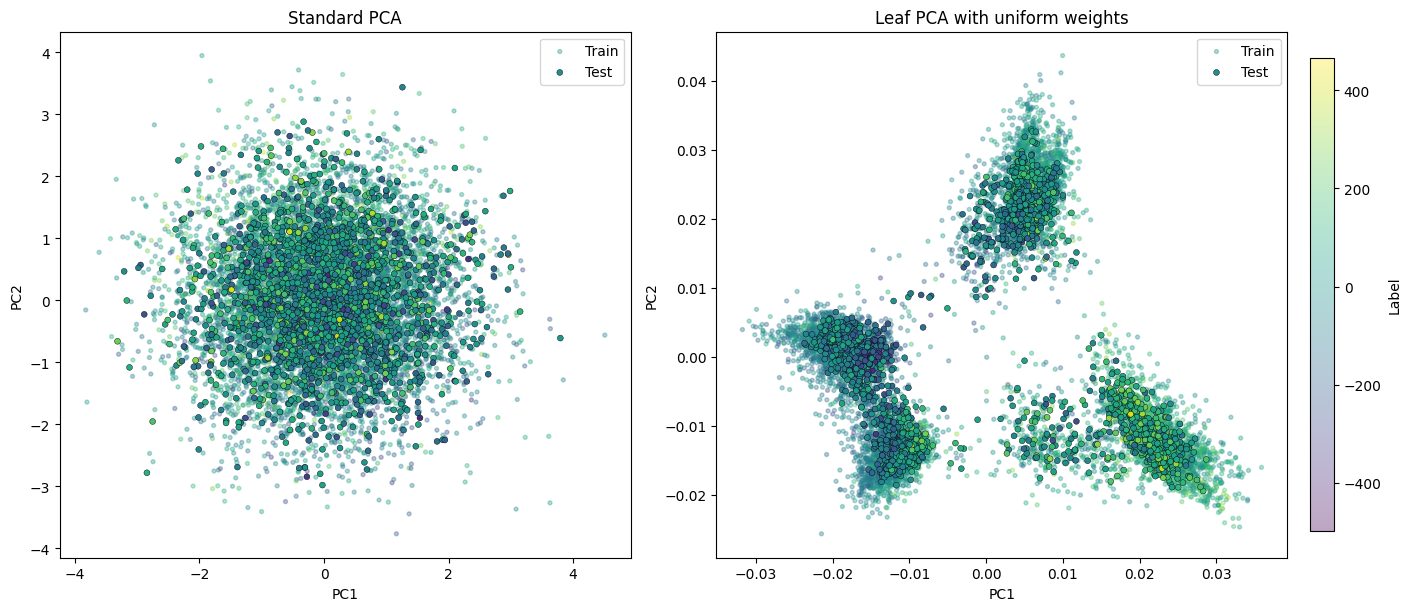

In [8]:
# Reusable plot: standard PCA vs leaf PCA (uniform weights)
plot_pca_vs_leaf_pca(Z_train, Z_test, Z_train_leaf, Z_test_leaf, y_train, y_test,
                     title_left="Standard PCA",
                     title_right="Leaf PCA with uniform weights")

### Observations

Leaf PCA tends to separate the continuous target signal and is less dominated by noisy raw features compared with standard PCA. We often observe a slight shift between training and test leaf embeddings: test points may activate rarer leaves more frequently, a pattern consistent with mild overfitting in leaf space.

### Rare-leaf shift diagnostic

The two plots below summarize how often samples activate leaves that are rare in the training set (bottom 10% of nonzero leaf counts). The "share" is the fraction of a sample’s active leaf assignments that land in those rare leaves. The left plot colors the leaf-PCA embedding by this share; the right plot shows train/test histograms comparing the share distributions.

In [9]:
def plot_rare_leaf_shift_diagnostic(cache, leaf_train, leaf_test, embedding_train, embedding_test, is_weighted=False, rare_quantile=0.10, eps=1e-12):
    """Rare-leaf shift diagnostic.

    If ``is_weighted`` is True, nonzero entries in ``leaf_train`` are treated as
    per-leaf weights (KeRF-style, typically 1/sqrt(leaf_mass)). If False, the
    function computes the original unweighted share of active leaves that are
    in the rare set.
    """
    # per-leaf counts and rare-leaf mask
    train_leaf_counts = np.asarray(leaf_train.getnnz(axis=0)).ravel().astype(np.float32)
    positive_counts = train_leaf_counts[train_leaf_counts > 0]
    rare_threshold = np.quantile(positive_counts, rare_quantile)
    rare_mask = train_leaf_counts <= rare_threshold

    if is_weighted:
        # extract a representative per-leaf weight from the sparse training matrix
        leaf_train_csc = leaf_train.tocsc()
        col_ptr = leaf_train_csc.indptr
        nz_cols = np.diff(col_ptr) > 0
        per_leaf_weight = np.zeros(leaf_train_csc.shape[1], dtype=np.float32)
        per_leaf_weight[nz_cols] = leaf_train_csc.data[col_ptr[:-1][nz_cols]]

        # TRAIN (weighted) - aggregate via flattened cache arrays for speed
        weights_all = per_leaf_weight[cache.flat_cols]
        weights_rare = weights_all * rare_mask[cache.flat_cols]
        train_num = np.bincount(cache.flat_rows, weights=weights_rare, minlength=cache.n_samples).astype(np.float32)
        train_den = np.bincount(cache.flat_rows, weights=weights_all, minlength=cache.n_samples).astype(np.float32)
        train_share = train_num / (train_den + eps)

        # TEST (weighted)
        test_indicator = leaf_test.copy()
        test_indicator.data = np.ones_like(test_indicator.data, dtype=np.float32)
        test_den = np.asarray(test_indicator.dot(per_leaf_weight)).ravel()
        test_num = np.asarray(test_indicator[:, rare_mask].dot(per_leaf_weight[rare_mask])).ravel()
        test_share = test_num / (test_den + eps)

    else:
        # UNWEIGHTED diagnostic (original behavior)
        train_rare_counts = np.bincount(cache.flat_rows[rare_mask[cache.flat_cols]], minlength=cache.n_samples).astype(np.float32)
        train_share = train_rare_counts / cache.n_trees

        test_indicator = leaf_test.copy()
        test_indicator.data = np.ones_like(test_indicator.data, dtype=np.float32)
        test_den = test_indicator.getnnz(axis=1).astype(np.float32)
        test_share = np.asarray(test_indicator[:, rare_mask].sum(axis=1)).ravel() / (test_den + eps)

    # Rarity scores (inv-sqrt counts)
    inv_sqrt_leaf_counts = 1.0 / np.sqrt(train_leaf_counts + 1.0)
    train_rarity_score = np.bincount(cache.flat_rows, weights=inv_sqrt_leaf_counts[cache.flat_cols], minlength=cache.n_samples).astype(np.float32) / cache.n_trees
    test_rarity_score = np.asarray(test_indicator.dot(inv_sqrt_leaf_counts)).ravel() / (test_indicator.getnnz(axis=1).astype(np.float32) + eps)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    scatter = axes[0].scatter(
        embedding_train[:, 0], embedding_train[:, 1],
        c=train_share, cmap="magma", s=10, alpha=0.35, label="Train",
    )
    axes[0].scatter(
        embedding_test[:, 0], embedding_test[:, 1],
        c=test_share, cmap="magma", s=20, edgecolor="black", linewidth=0.3, label="Test",
    )
    title = "KeRF-weighted rare-leaf share" if is_weighted else "Unweighted rare-leaf share"
    axes[0].set_title(f"Leaf PCA colored by {title}")
    axes[0].set_xlabel("PC1")
    axes[0].set_ylabel("PC2")
    axes[0].legend(frameon=False)
    fig.colorbar(scatter, ax=axes[0], label="share in rare leaves")

    bins = np.linspace(0, max(np.nanmax(train_share), np.nanmax(test_share)), 35)
    axes[1].hist(train_share, bins=bins, alpha=0.6, density=True, label="Train")
    axes[1].hist(test_share, bins=bins, alpha=0.6, density=True, label="Test")
    axes[1].axvline(np.nanmean(train_share), color="C0", linestyle="--", linewidth=1)
    axes[1].axvline(np.nanmean(test_share), color="C1", linestyle="--", linewidth=1)
    axes[1].set_title("Distribution of rare-leaf share")
    axes[1].set_xlabel("share of activations in rare leaves")
    axes[1].set_ylabel("density")
    axes[1].legend(frameon=False)

    plt.tight_layout()

    print(f"rare-leaf threshold (quantile={rare_quantile}): {rare_threshold:.3f}")
    print(f"mean share, train: {np.nanmean(train_share):.4f}")
    print(f"mean share, test : {np.nanmean(test_share):.4f}")
    print(f"mean rarity score, train: {np.nanmean(train_rarity_score):.4f}")
    print(f"mean rarity score, test : {np.nanmean(test_rarity_score):.4f}")


rare-leaf threshold (quantile=0.1): 1.000
mean share, train: 0.3862
mean share, test : 0.4410
mean rarity score, train: 0.5961
mean rarity score, test : 0.6070


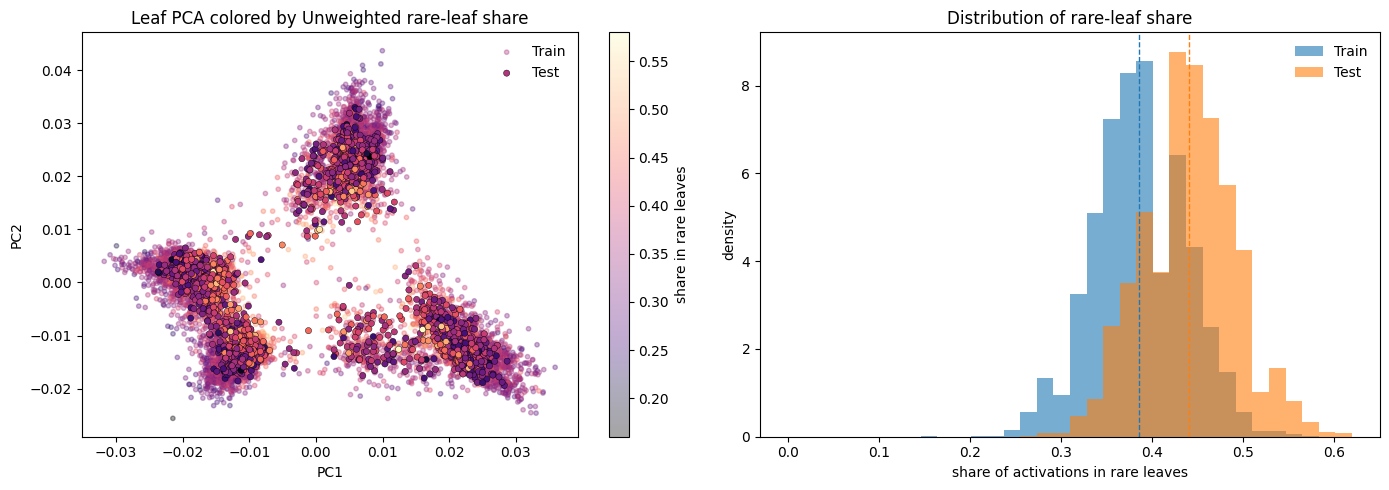

In [10]:
# Run weighted diagnostic (uniform setting)
plot_rare_leaf_shift_diagnostic(encoder.cache_, leaf_train, leaf_test, Z_train_leaf, Z_test_leaf, is_weighted=False)

## OOB analysis

When `weight_scheme='oob'`, the train/test shift can be amplified by bootstrap effects. Under the separable OOB approximation, out-of-sample leaf embeddings have unit norm while training OOB leaf maps are inflated by approximately $\sqrt{T / |S_i|}$, where $|S_i|$ is the number of trees for which a sample is OOB. The following section compares PCA projections under this weighting and discusses mitigation strategies.

### OOB: geometric intuition

Let $P_k$ denote the orthogonal projection onto the first $k$ principal directions learned by PCA. Since orthogonal projections are non-expansive,
$$
\|P_k x\|_2 \leq \|x\|_2.
$$

Under the separable OOB construction, training OOB leaf maps have inflated norms approx. $\sqrt{T/|S_i|}$ while out-of-sample leaf maps have unit norm. Hence any inflation component lying in the PCA subspace will persist in projected embeddings, explaining why PCA cannot fully remove the OOB-induced train/test mismatch.

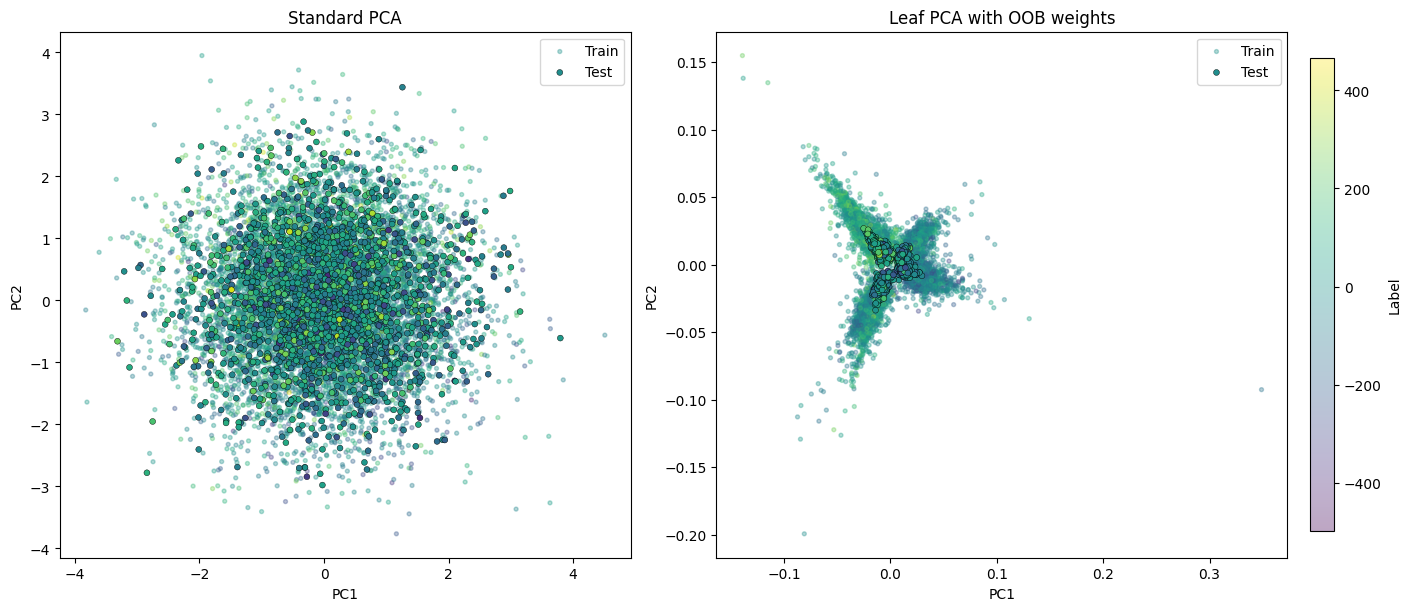

In [11]:
# Switch encoder to OOB weighting, rebuild leaf maps on top of
# the trained base forest using set_weight_scheme to avoid refitting,
# retrain PCA on leaf space, and compare
encoder.set_weight_scheme('oob')

# Get OOB-weighted leaf maps
leaf_train_oob = encoder.training_query_map()
leaf_test_oob = encoder.transform(X_test)

# Fit PCA on the OOB training leaf map and project both train and test
pca_oob = PCA(n_components=2, random_state=seed)
pca_oob.fit(leaf_train_oob)
Z_train_leaf_oob = pca_oob.transform(leaf_train_oob)
Z_test_leaf_oob = pca_oob.transform(leaf_test_oob)

# Reuse standard PCA results (Z_train, Z_test) and compare with OOB leaf PCA
plot_pca_vs_leaf_pca(Z_train, Z_test, Z_train_leaf_oob, Z_test_leaf_oob, y_train, y_test,
                     title_left="Standard PCA",
                     title_right="Leaf PCA with OOB weights")

One way to mitigate this effect is to instead project the inductive training leaf maps using the OOB Leaf PCA operator, that is, by treating the training samples as out-of-sample for all trees during projection. In this setting, both the training and test leaf embeddings have unit $\ell_2$ norm, thereby removing the train/test norm mismatch induced by the OOB scaling. However, this also reintroduces the “rare-leaf” shift observed previously in the uniform-weight setting, where out-of-sample points tend to activate smaller or less represented leaves than the fitted training maps.

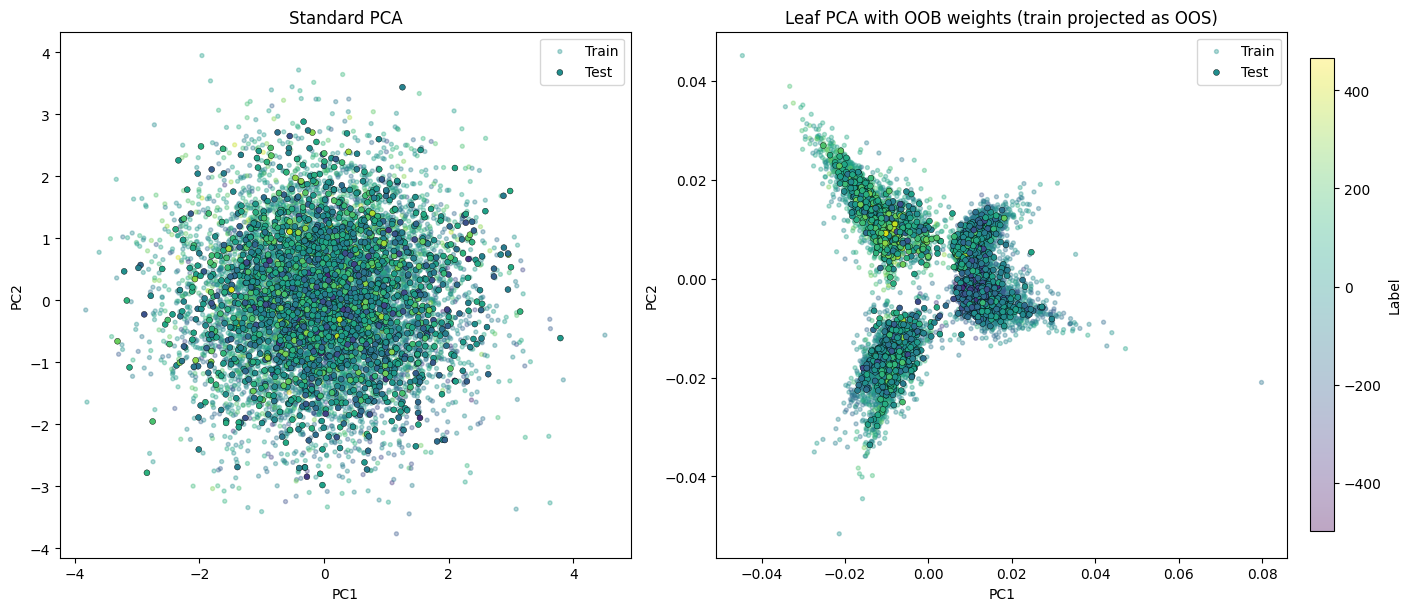

In [12]:
leaf_train_oob_as_oos = encoder.transform(X_train)  # treat train as OOS for projection
Z_train_leaf_oob_as_oos = pca_oob.transform(leaf_train_oob_as_oos)
Z_test_leaf_oob = pca_oob.transform(leaf_test_oob)

# Reuse standard PCA results (Z_train, Z_test) and compare with OOB leaf PCA
plot_pca_vs_leaf_pca(Z_train, Z_test, Z_train_leaf_oob_as_oos, Z_test_leaf_oob, y_train, y_test,
                     title_left="Standard PCA",
                     title_right="Leaf PCA with OOB weights (train projected as OOS)")

## KeRF analysis

KeRF (Kernel Random Forest) reduces the disproportionate influence of large leaves by normalizing each leaf coordinate by the square root of its training mass. This mass-normalization recovers a collision-based proximity that accounts for leaf size, which often stabilizes training variance and mitigates the train/test norm mismatch introduced by raw OOB scaling.

Below we compute PCA in the KeRF-weighted leaf space and run a diagnostic that measures the fraction of the *KeRF-weighted* activation mass assigned to small (rare) leaves. Under KeRF, weighting by 1/sqrt(leaf_mass) is the appropriate statistic as it reflects each leaf’s contribution to the mass-normalized proximity rather than a raw count of activations.

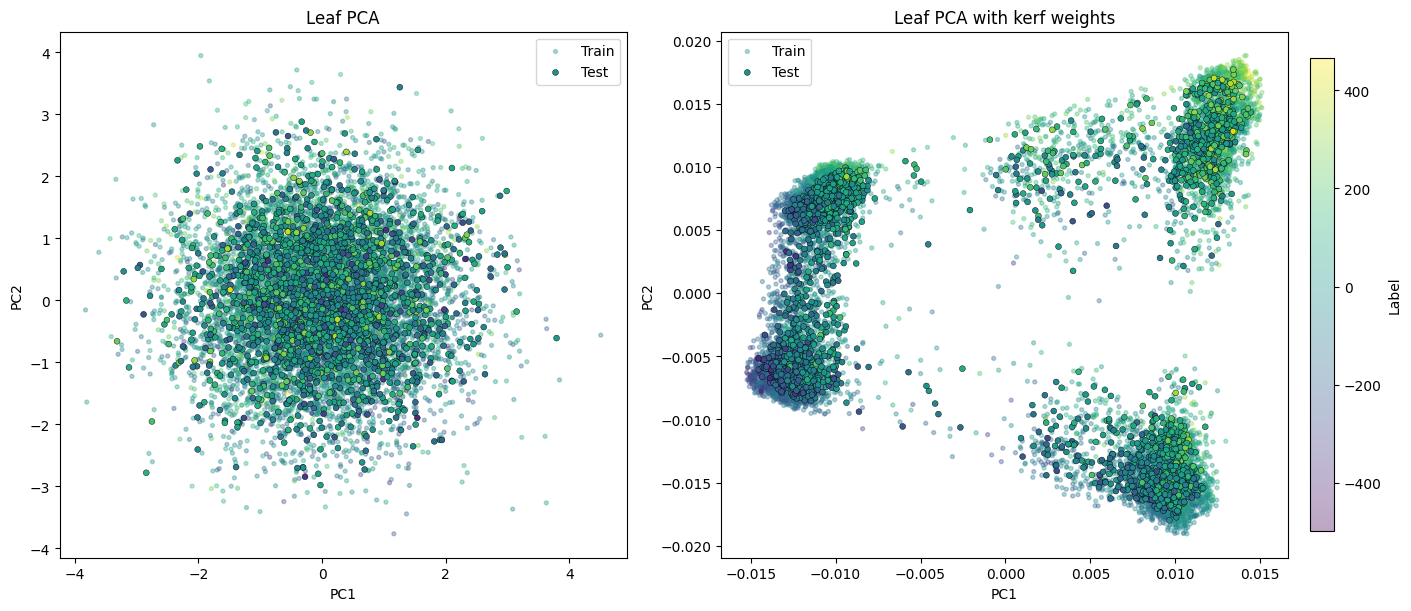

In [13]:
# Switch encoder to OOB weighting, rebuild leaf maps on top of
# the trained base forest using set_weight_scheme to avoid refitting,
# retrain PCA on leaf space, and compare
encoder.set_weight_scheme('kerf')

# Get kerf-weighted leaf maps
leaf_train_kerf = encoder.training_query_map()
leaf_test_kerf = encoder.transform(X_test)

# Fit PCA on the kerf training leaf map and project both train and test
pca_kerf = PCA(n_components=2, random_state=seed)
pca_kerf.fit(leaf_train_kerf)
Z_train_leaf_kerf = pca_kerf.transform(leaf_train_kerf)
Z_test_leaf_kerf = pca_kerf.transform(leaf_test_kerf)

# Reuse standard PCA results (Z_train, Z_test) and compare with kerf leaf PCA
plot_pca_vs_leaf_pca(Z_train, Z_test, Z_train_leaf_kerf, Z_test_leaf_kerf, y_train, y_test,
                     title_left="Leaf PCA",
                     title_right="Leaf PCA with kerf weights")

rare-leaf threshold (quantile=0.1): 1.000
mean share, train: 0.5003
mean share, test : 0.5556
mean rarity score, train: 0.5961
mean rarity score, test : 0.6070


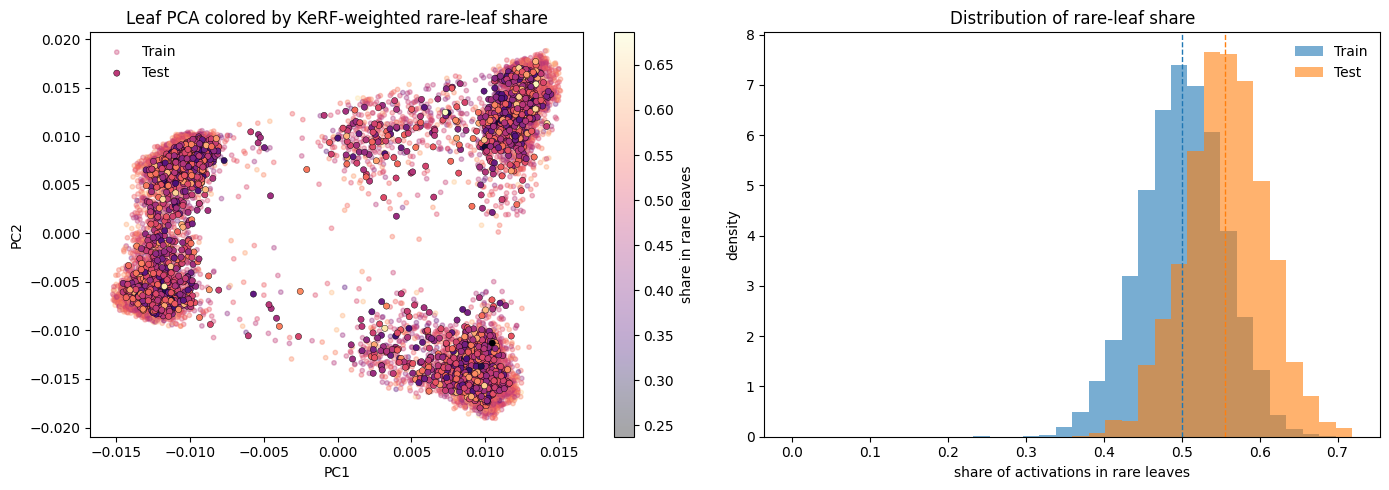

In [14]:
# Run weighted diagnostic for KeRF setting
plot_rare_leaf_shift_diagnostic(encoder.cache_, leaf_train_kerf, leaf_test_kerf, Z_train_leaf_kerf, Z_test_leaf_kerf, is_weighted=True)

# Stabilizing Leaf PCA
## Via leaf size constraints
A mild constraint such as `min_samples_leaf=3` can stabilize the leaf PCA embedding while preserving the overall structure seen in the unconstrained forest. By preventing very small leaves, it reduces the rare-leaf effect and narrows the observed train/test shift.

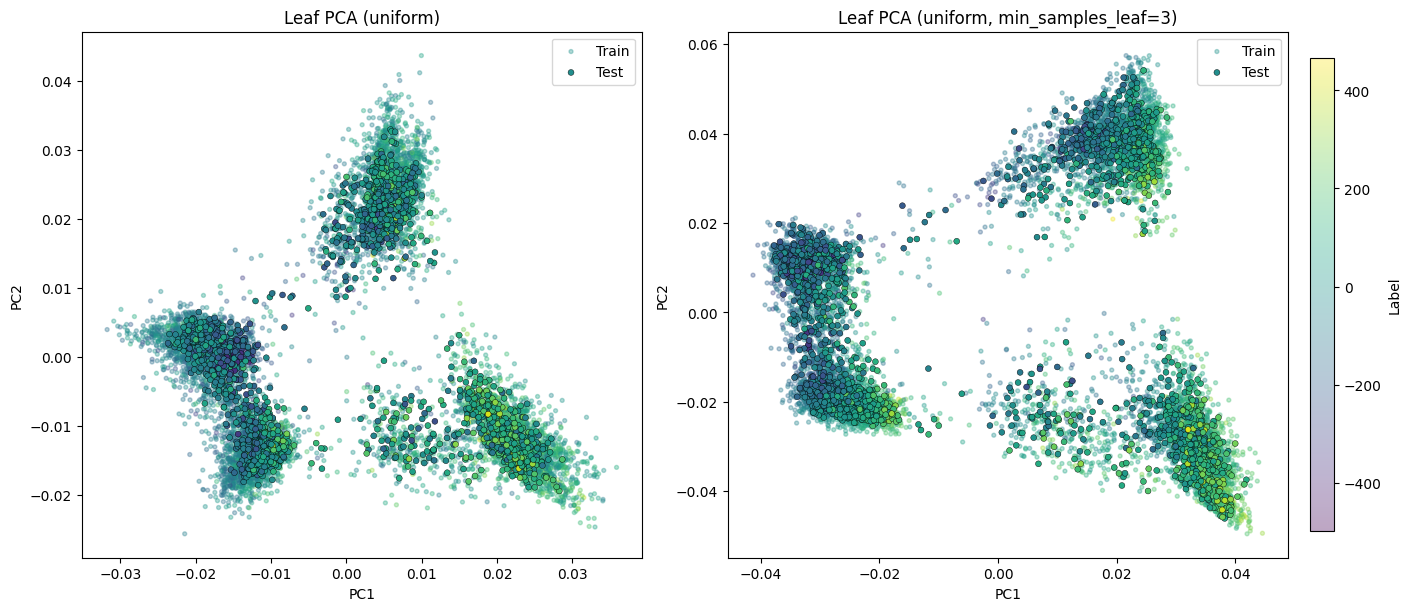

rare-leaf threshold (quantile=0.1): 3.000
mean share, train: 0.0702
mean share, test : 0.0741
mean rarity score, train: 0.3784
mean rarity score, test : 0.3798


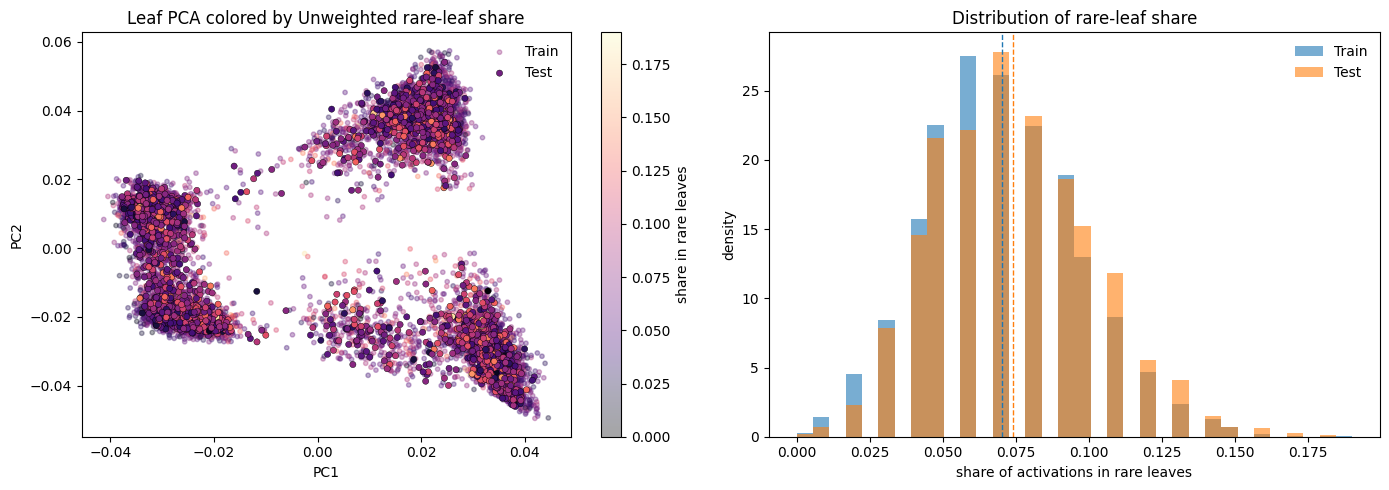

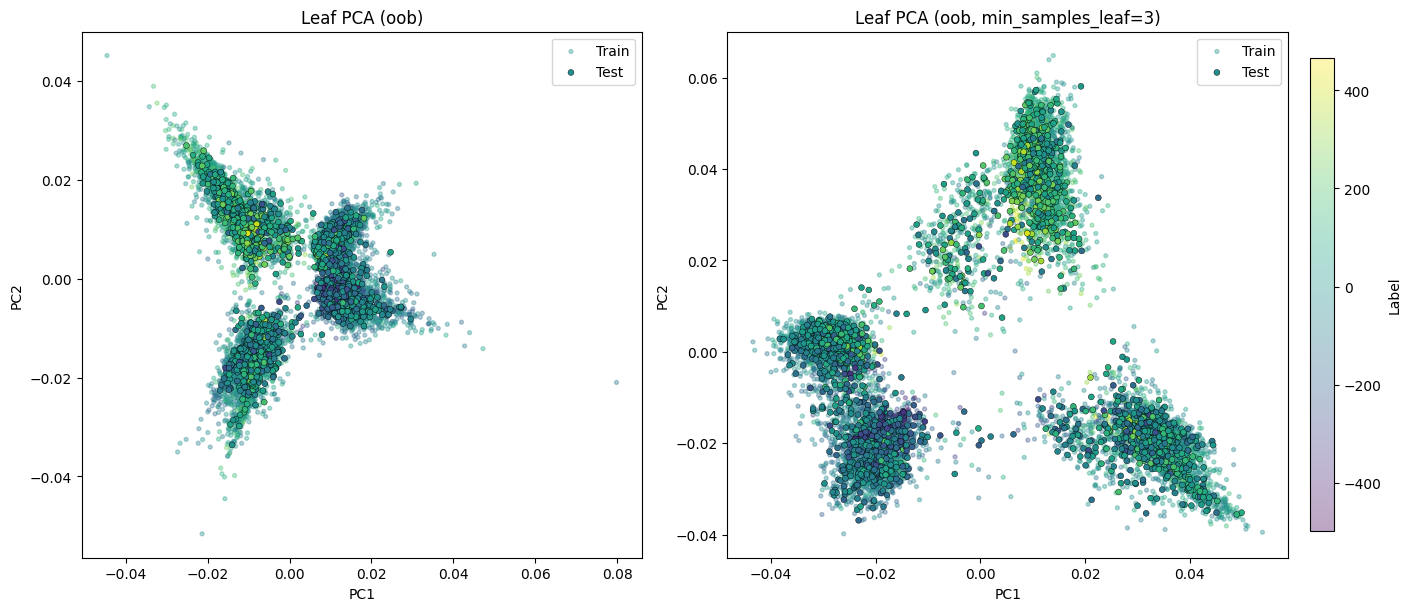

rare-leaf threshold (quantile=0.1): 1.000
mean share, train: 0.3119
mean share, test : 0.3235
mean rarity score, train: 0.5859
mean rarity score, test : 0.5908


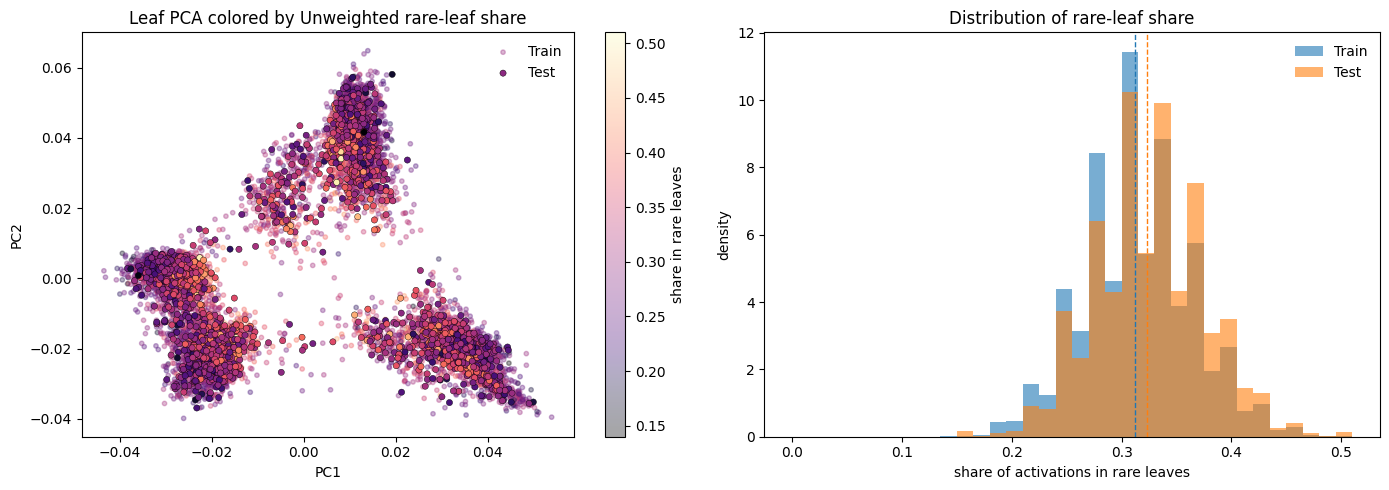

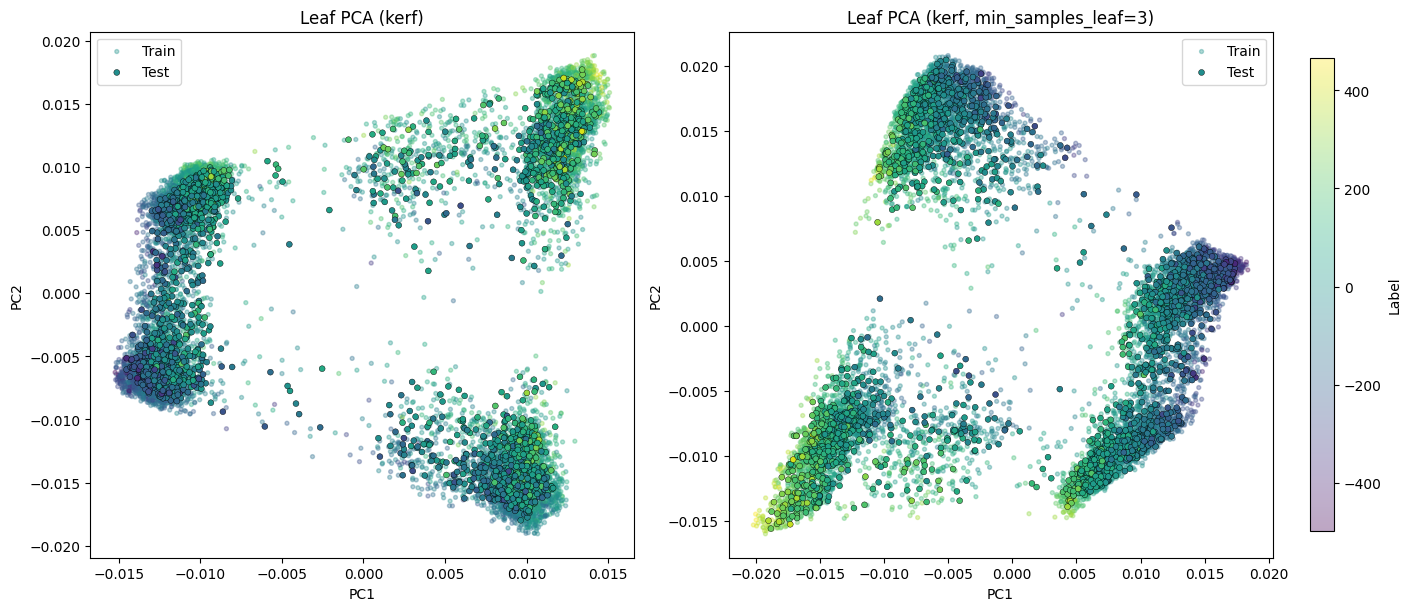

rare-leaf threshold (quantile=0.1): 3.000
mean share, train: 0.0979
mean share, test : 0.1030
mean rarity score, train: 0.3784
mean rarity score, test : 0.3798


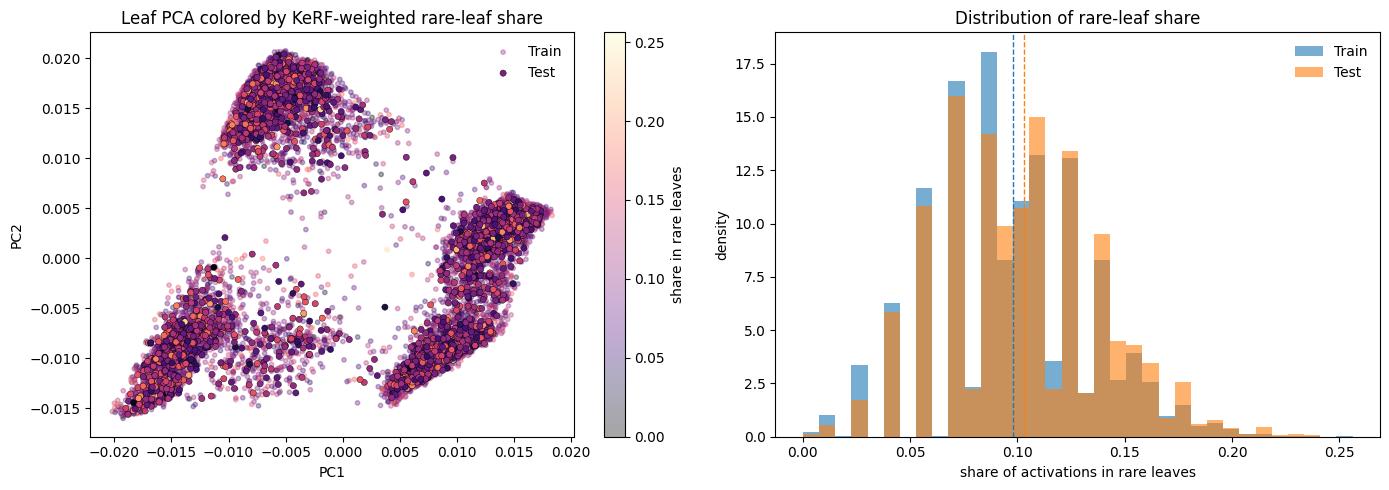

In [15]:
for weight_scheme in ("uniform", "oob", "kerf"):
    forest = RandomForestRegressor(
        bootstrap=True,
        n_jobs=-1,
        random_state=seed,
        min_samples_leaf=3,
    )
    enc = LeafEncoder(forest=forest, weight_scheme=weight_scheme).fit(X_train, y_train)
    leaf_train_min_samples_leaf = enc.training_query_map()
    leaf_train_min_samples_leaf_as_oos = enc.transform(X_train)
    leaf_test_min_samples_leaf = enc.transform(X_test)

    pca_min_samples_leaf = PCA(n_components=2, random_state=seed)
    pca_min_samples_leaf.fit(leaf_train_min_samples_leaf)
    Z_train_leaf_min_samples_leaf = pca_min_samples_leaf.transform(leaf_train_min_samples_leaf_as_oos)
    Z_test_leaf_min_samples_leaf = pca_min_samples_leaf.transform(leaf_test_min_samples_leaf)
    if weight_scheme == "uniform":
        Z_train = Z_train_leaf
        Z_test = Z_test_leaf
    elif weight_scheme == "oob":
        Z_train = Z_train_leaf_oob_as_oos
        Z_test = Z_test_leaf_oob
    elif weight_scheme == "kerf":
        Z_train = Z_train_leaf_kerf
        Z_test = Z_test_leaf_kerf

    plot_pca_vs_leaf_pca(
        Z_train,
        Z_test,
        Z_train_leaf_min_samples_leaf,
        Z_test_leaf_min_samples_leaf,
        y_train,
        y_test,
        title_left=f"Leaf PCA ({weight_scheme})",
        title_right=f"Leaf PCA ({weight_scheme}, min_samples_leaf=3)",
    )
    plot_rare_leaf_shift_diagnostic(
        enc.cache_,
        leaf_train_min_samples_leaf,
        leaf_test_min_samples_leaf,
        Z_train_leaf_min_samples_leaf,
        Z_test_leaf_min_samples_leaf,
        is_weighted=(weight_scheme == "kerf"),
    )

# Leaf PCA (Classification)

Leaf PCA can also be applied to classification problems. Because class labels
constrain the target variability, leaf-space PCA embeddings for classification
are often more stable than in regression (particularly when classes are
reasonably balanced). This reduces the occurrence of very small or
singleton leaves that can distort embeddings and downstream diagnostics.

Classification dataset: 8000 train, 2000 test samples, 30 features, 5 classes


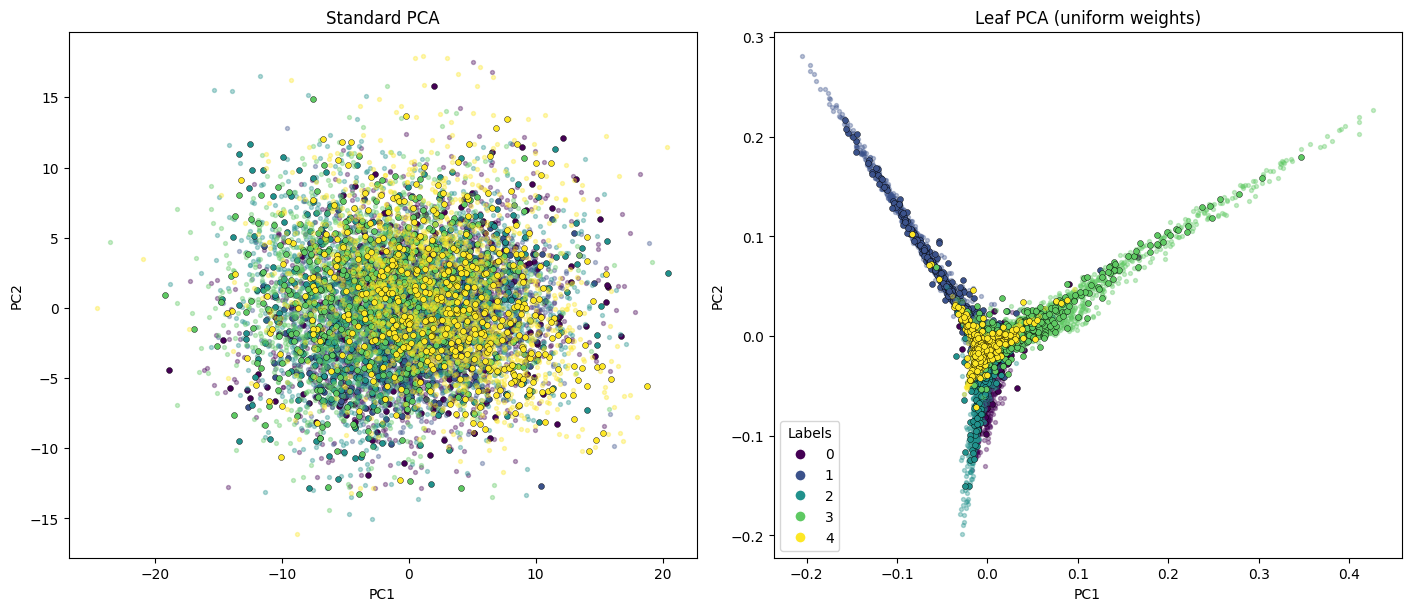

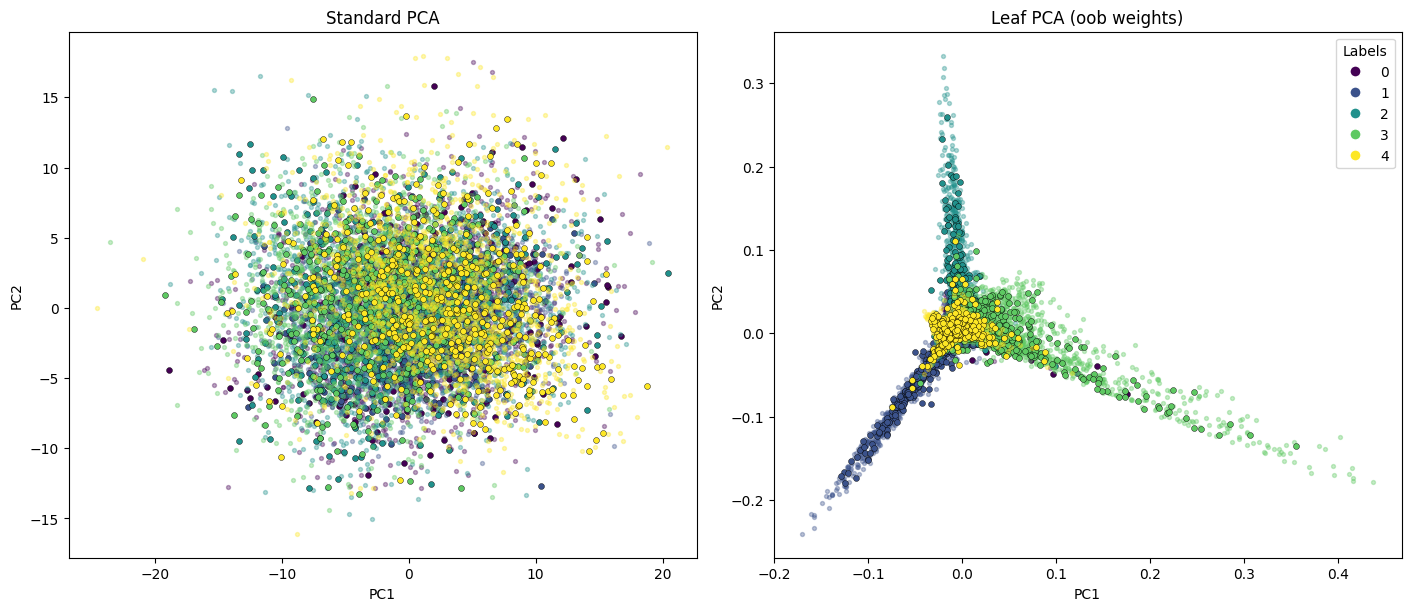

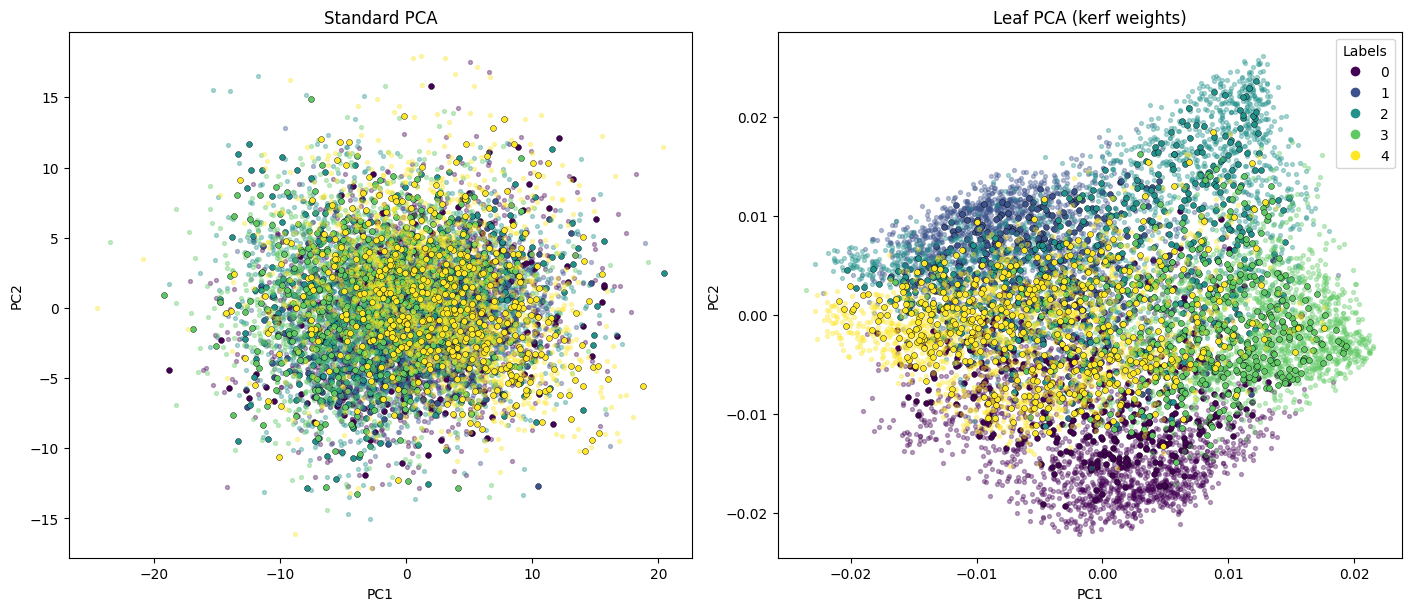

In [18]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

# Generate larger synthetic classification dataset
X_clf, y_clf = make_classification(
    n_samples=10000,
    n_features=30,
    n_informative=15,
    n_classes=5,
    random_state=seed,
)

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=seed
)

print(f"Classification dataset: {X_train_iris.shape[0]} train, {X_test_iris.shape[0]} test samples, {X_train_iris.shape[1]} features, {len(np.unique(y_train_iris))} classes")

# Standard PCA (computed once, reused for all plots)
pca_clf = PCA(n_components=2, random_state=seed)
pca_clf.fit(X_train_iris)
Z_train_clf = pca_clf.transform(X_train_iris)
Z_test_clf = pca_clf.transform(X_test_iris)

# Loop over weight schemes
for ws in ('uniform', 'oob', 'kerf'):
    encoder_clf = LeafEncoder(forest=RandomForestClassifier(bootstrap=True,
                                                            n_jobs=-1,
                                                            random_state=seed
                                                            ),
                              weight_scheme=ws).fit(X_train_iris, y_train_iris)
    
    leaf_train_clf = encoder_clf.training_query_map()
    leaf_train_clf_oos = encoder_clf.transform(X_train_iris)
    leaf_test_clf = encoder_clf.transform(X_test_iris)
    
    pca_leaf_clf = PCA(n_components=2, random_state=seed)
    pca_leaf_clf.fit(leaf_train_clf)
    Z_train_leaf_clf = pca_leaf_clf.transform(leaf_train_clf_oos)
    Z_test_leaf_clf = pca_leaf_clf.transform(leaf_test_clf)
    
    plot_pca_vs_leaf_pca(Z_train_clf, Z_test_clf, Z_train_leaf_clf, Z_test_leaf_clf,
                         y_train_iris, y_test_iris,
                         title_left="Standard PCA",
                         title_right=f"Leaf PCA ({ws} weights)")